In [22]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.colors import Normalize
import pickle

freq_in_thz = 6.3507799295888985
t_in_ps = 1 / freq_in_thz

OUTDIR = Path("combined_summary_fig")
OUTDIR.mkdir(exist_ok=True)

def load_txt_2d(path):
    return np.atleast_2d(np.loadtxt(path))

def load_txt_1d(path):
    return np.atleast_1d(np.loadtxt(path)).ravel()

def get_protocol_series(traj):
    keys = [
        "A", "A_t", "A_used", "A_t_used",
        "protocol", "protocol_used",
        "field", "field_used",
        "pulse", "pulse_used",
        "E_t", "E_used",
        "drive", "drive_used",
        "normA2_used",
        "all_nn_ifft",
    ]
    Nt = len(traj["t"])
    for key in keys:
        if key in traj:
            arr = np.asarray(traj[key]).squeeze()
            if arr.ndim == 1 and len(arr) == Nt:
                return arr, key
    return None, None

def load_displacive_best_items(pklfile, c2_scale_to_use=None):
    with open(pklfile, "rb") as f:
        all_results = pickle.load(f)

    if c2_scale_to_use is None:
        c2_scale_to_use = list(all_results.keys())[0]

    compact = all_results[c2_scale_to_use]
    score_entries = compact["score_vs_gen"]

    gens = np.array([e["gen"] for e in score_entries], dtype=int)

    max_pop = max(len(np.asarray(e["all_scores"]).ravel()) for e in score_entries)
    scores = np.full((len(score_entries), max_pop), np.nan)

    for i, e in enumerate(score_entries):
        s = np.asarray(e["all_scores"], dtype=float).ravel()
        scores[i, :len(s)] = s

    idxs = [0, len(score_entries)//2, len(score_entries)-1]
    idxs = list(dict.fromkeys(idxs))

    x_list, v_list, A_list, labels = [], [], [], []

    for idx in idxs:
        entry = score_entries[idx]
        gen = int(entry["gen"])

        if "best_traj" in entry:
            traj = entry["best_traj"]
        elif "top3_traj" in entry:
            traj = entry["top3_traj"][0]
        elif "all_traj" in entry:
            traj = entry["all_traj"][int(entry["best_pop_idx"])]
        else:
            raise KeyError(f"No trajectory found for Gen {gen}")

        x = np.asarray(traj["x"])
        v = np.asarray(traj["v"])
        A, _ = get_protocol_series(traj)

        if A is None:
            A = np.zeros_like(x)

        x_list.append(x)
        v_list.append(v)
        A_list.append(A)
        labels.append(f"Gen {gen}")

    t_ps = np.asarray(traj["t"]) * t_in_ps

    return {
        "gens": gens,
        "scores": scores,
        "x": np.asarray(x_list),
        "v": np.asarray(v_list),
        "A": np.asarray(A_list),
        "t_ps": t_ps,
        "labels": labels,
        "c2_scale": c2_scale_to_use,
    }


# ============================================================
# ROW 1 — CW Raman, 1D PES
# ============================================================

cw1_dir = Path("Data")

cw1_scores = load_txt_2d(cw1_dir / "scores_all_gen_pop_2b.dat")
cw1_gen = load_txt_1d(cw1_dir / "gen_all_gen_pop_2b.dat")

cw1_x = load_txt_2d(cw1_dir / "sol_x_all_gen_pop_2c.dat")
cw1_v = load_txt_2d(cw1_dir / "sol_v_all_gen_pop_2c.dat")
cw1_A = load_txt_2d(cw1_dir / "protocol_all_gen_pop_2d.dat")

cw1_t = np.linspace(0, 20, cw1_x.shape[1])

cw1_sel = [0, 2, 4, 5]
cw1_x_sel = cw1_x[cw1_sel]
cw1_v_sel = cw1_v[cw1_sel]
cw1_A_sel = cw1_A[cw1_sel]
cw1_labels = ["Gen 0", "Gen 31", "Gen 33", "Gen 62"]


# ============================================================
# ROW 2 — CW Raman, 3D PES
# ============================================================

cw3d_dir = Path("../multiple_modes_dft_test/Data")

cw3d_bundle = np.load(cw3d_dir / "selected_protocol_bundle.npz", allow_pickle=True)

cw3d_scores = load_txt_2d(cw3d_dir / "scores_all_gen_pop_2b.dat")
cw3d_gen = load_txt_1d(cw3d_dir / "gen_all_gen_pop_2b.dat")

sel_gen = cw3d_bundle["sel_gen"]
sel_time = cw3d_bundle["sel_time"]
sel_q = cw3d_bundle["sel_q"]
sel_v = cw3d_bundle["sel_v"]
sel_At_norm = cw3d_bundle["sel_At_norm"]
t_eval = cw3d_bundle["t_eval"]

cw3d_sel = [0, len(sel_gen)//2, len(sel_gen)-1]
cw3d_sel = list(dict.fromkeys(cw3d_sel))

cw3d_x_sel = sel_q[cw3d_sel, 0, :]
cw3d_v_sel = sel_v[cw3d_sel, 0, :]
cw3d_A_sel = sel_At_norm[cw3d_sel, :]

cw3d_t = np.asarray(sel_time[cw3d_sel[0]]) * t_in_ps
cw3d_tA = np.asarray(t_eval) * t_in_ps

cw3d_A_interp = np.asarray([
    np.interp(cw3d_t, cw3d_tA, y)
    for y in cw3d_A_sel
])

cw3d_labels = [f"Gen {int(sel_gen[i])}" for i in cw3d_sel]


# ============================================================
# ROW 3 — Pulsed Raman, 1D PES
# ============================================================

pr_dir = Path("../Fig3/Data")

pr_scores = load_txt_2d(pr_dir / "scores_3b.dat")
pr_gen = load_txt_1d(pr_dir / "gen_3b.dat")

pr_x = load_txt_2d(pr_dir / "sol_x_3c.dat")
pr_v = load_txt_2d(pr_dir / "sol_v_3c.dat")
pr_A = load_txt_2d(pr_dir / "protocol_3d.dat")

pr_t = np.linspace(0, 20, pr_x.shape[1])
pr_labels = ["Gen 0", "Gen 4", "Gen 179"]


# ============================================================
# ROW 4 — Pulsed displacive EOM
# ============================================================

disp_data = load_displacive_best_items(
    Path("../../compact_full_all_pop_all_gen.pkl"),
    c2_scale_to_use=None,
)

Saved:
combined_summary_fig/combined_scores_fig2_color_coded.pdf


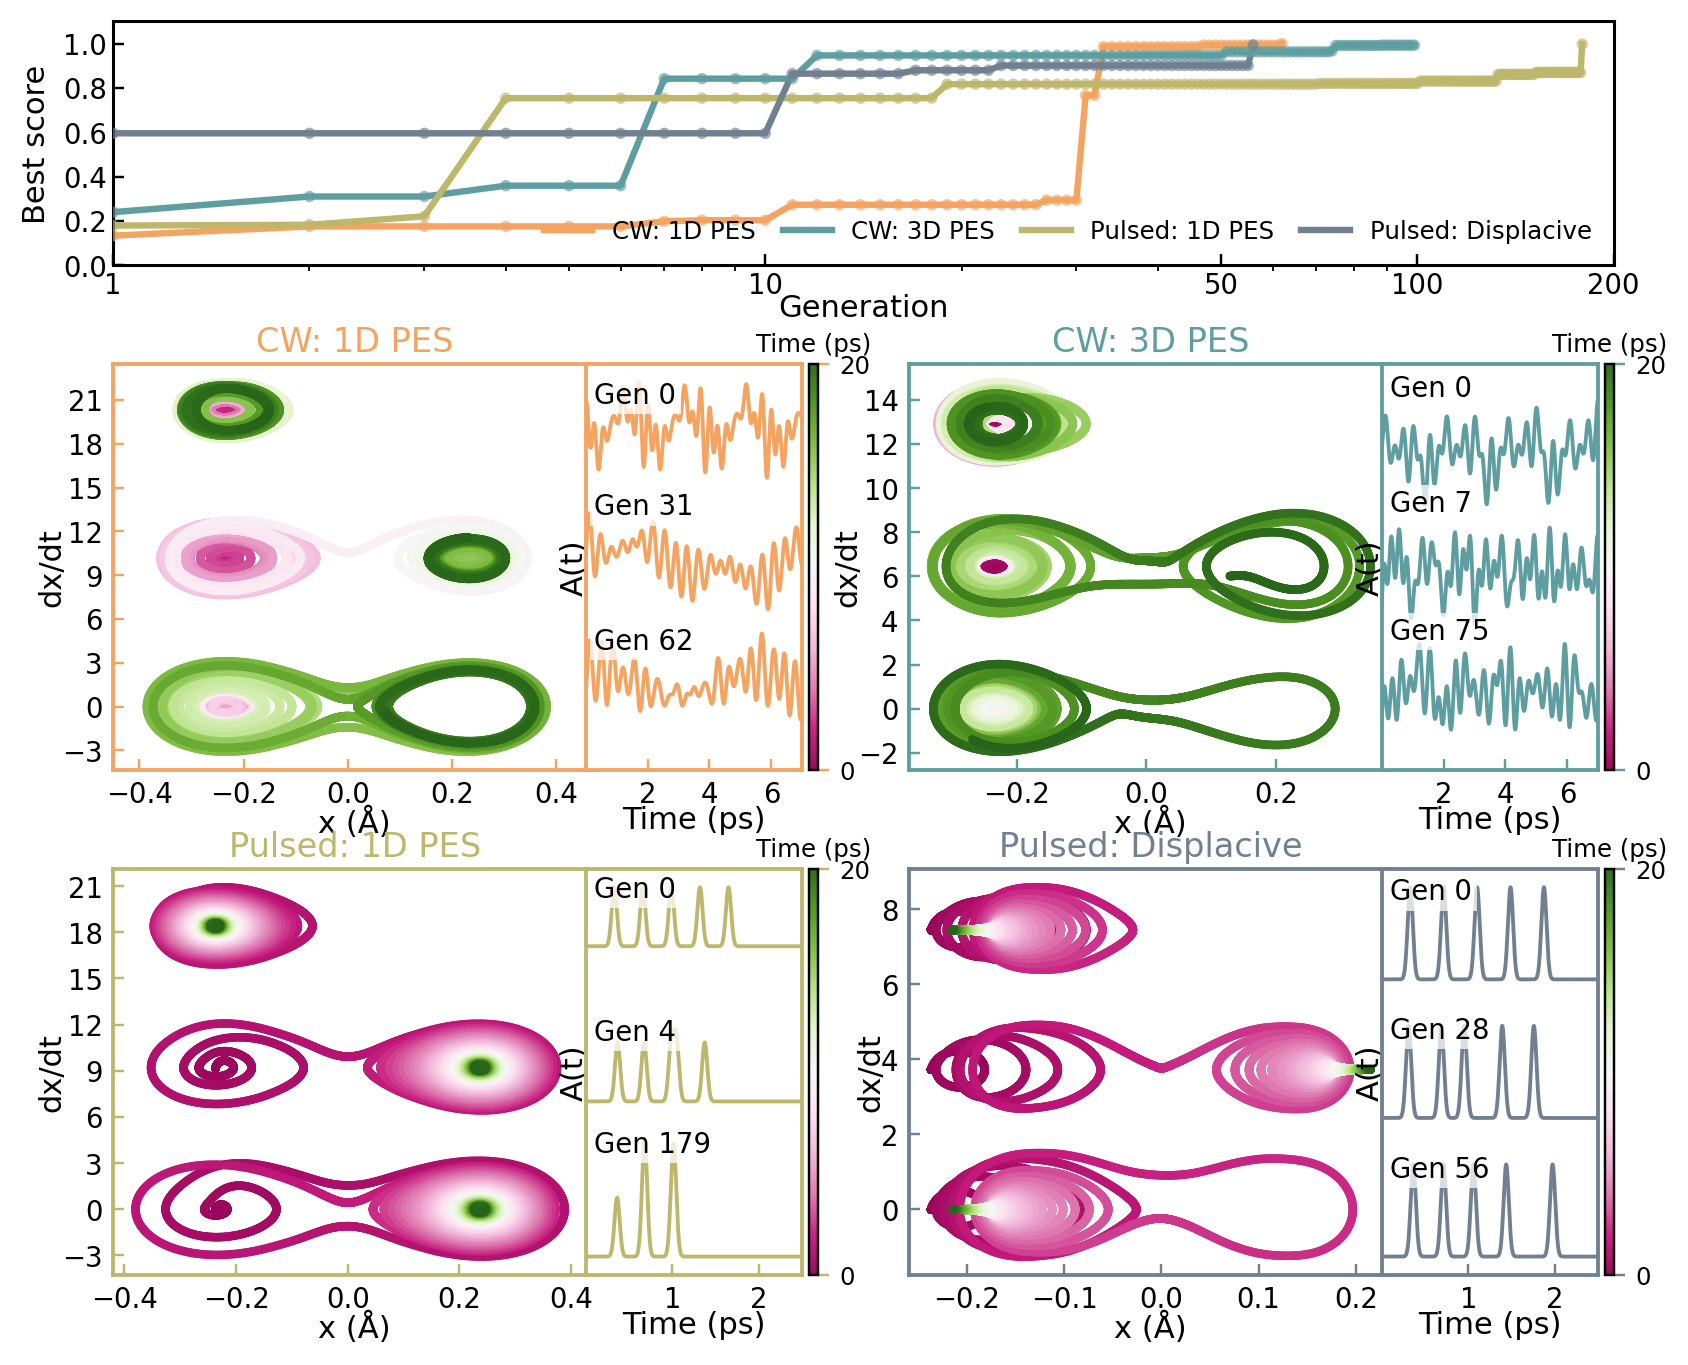

In [82]:
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.ticker import MaxNLocator
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.ticker import FormatStrFormatter
from matplotlib.ticker import MultipleLocator, FormatStrFormatter
import numpy as np

plt.rcParams.update({
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 12,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 8,
})

# ------------------------------------------------------------
# Shared 4-color palette
# ------------------------------------------------------------
#colors = ["peru", "cadetblue", "darkkhaki", "slategray"]
colors = ["sandybrown", "cadetblue", "darkkhaki", "slategray"]

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------

def plot_score_panel(ax, gen_no, scores, title, color="gray"):
    scores = np.atleast_2d(scores)
    gen_no = np.atleast_1d(gen_no).ravel()

    if scores.shape[0] != len(gen_no) and scores.shape[1] == len(gen_no):
        scores = scores.T

    best_scores = np.nanmax(scores, axis=1)

    ax.scatter(
        gen_no,
        best_scores,
        alpha=0.75,
        edgecolor="none",
        color=color,
        s=28,
        zorder=3,
    )

    ax.plot(
        gen_no,
        best_scores,
        color=color,
        lw=1.8,
        zorder=2,
    )

    ax.set_xlabel("Generation")
    ax.set_ylabel("Best score")
    ax.tick_params(direction="in")
    ax.yaxis.set_major_locator(MultipleLocator(0.1))
    ax.yaxis.set_major_formatter(FormatStrFormatter("%.1f"))


def color_axis_box(ax, color, lw=1.25):
    for side in ["left", "right", "top", "bottom"]:
        ax.spines[side].set_color(color)
        ax.spines[side].set_linewidth(lw)

    ax.tick_params(
        axis="both",
        direction="in",
        color=color,
        labelcolor="black",
    )


def plot_joint_phase_protocol(
    fig,
    ax_phase,
    ax_protocol,
    x_all,
    v_all_internal,
    A_all,
    t_ps,
    labels,
    protocol_xlim,
    phase_xlim=None,
    phase_spacing=None,
    protocol_spacing=None,
    label_x_frac=0.04,
    label_y_frac=0.72,
    scatter_size=8,
    panel_color="k",
):
    x_all = np.asarray(x_all)
    v_all_internal = np.asarray(v_all_internal)
    A_all = np.asarray(A_all)
    t_ps = np.asarray(t_ps)

    # internal velocity = dx / d(internal time)
    # physical velocity = dx / d(ps) = v_internal / t_in_ps
    v_all = v_all_internal / t_in_ps

    n = len(x_all)

    norm = Normalize(vmin=np.min(t_ps), vmax=np.max(t_ps))

    if phase_spacing is None:
        vrange = np.nanmax(v_all) - np.nanmin(v_all)
        phase_spacing = 1.35 * vrange if vrange > 0 else 1.0

    if protocol_spacing is None:
        Arange = np.nanmax(A_all) - np.nanmin(A_all)
        protocol_spacing = 1.35 * Arange if Arange > 0 else 1.0

    sc = None

    for j in range(n):
        phase_offset = (n - 1 - j) * phase_spacing
        protocol_offset = (n - 1 - j) * protocol_spacing

        sc = ax_phase.scatter(
            x_all[j],
            v_all[j] + phase_offset,
            c=t_ps,
            cmap="PiYG",
            norm=norm,
            s=scatter_size,
            edgecolor="none",
            alpha=0.95,
        )

        ax_protocol.plot(
            t_ps,
            A_all[j] + protocol_offset,
            color=panel_color,
            lw=1.25,
        )

        ymin = np.nanmin(A_all[j] + protocol_offset)
        ymax = np.nanmax(A_all[j] + protocol_offset)
        y_text = ymin + label_y_frac * (ymax - ymin + 1e-12)

        ax_protocol.text(
            protocol_xlim[0] + label_x_frac * (protocol_xlim[1] - protocol_xlim[0]),
            y_text,
            labels[j],
            fontsize=9,
            ha="left",
            va="center",
            bbox=dict(facecolor="white", edgecolor="none", alpha=0.75, pad=1.5),
            zorder=10,
        )

    ax_phase.set_xlabel("x (Å)")
    ax_phase.set_ylabel("dx/dt")
    ax_phase.tick_params(direction="in")
    ax_phase.yaxis.set_major_locator(MaxNLocator(integer=True))

    ax_protocol.set_xlabel("Time (ps)")
    ax_protocol.set_ylabel("A(t)", labelpad=-1.0)
    ax_protocol.yaxis.set_label_position("left")
    ax_protocol.yaxis.tick_left()
    ax_protocol.set_xlim(*protocol_xlim)
    ax_protocol.set_yticklabels([])
    ax_protocol.tick_params(direction="in")

    if phase_xlim is not None:
        xmin, xmax = phase_xlim
        xpad_right = 0.03 * (xmax - xmin)

        ax_phase.set_xlim(xmin, xmax + xpad_right)
        ax_phase.margins(x=0)
        ax_phase.autoscale(enable=False, axis="x")

    # colorbar at end of protocol plot
    divider = make_axes_locatable(ax_protocol)
    cax = divider.append_axes("right", size="4%", pad=0.03)

    cbar = fig.colorbar(sc, cax=cax, orientation="vertical")
    cbar.ax.set_title("Time (ps)", fontsize=8, pad=4)
    cbar.set_ticks([norm.vmin, norm.vmax])
    cbar.ax.set_yticklabels([f"{norm.vmin:.0f}", f"{norm.vmax:.0f}"])
    cbar.ax.tick_params(labelsize=8)

    # --------------------------------------------------------
    # Color-coded phase-space box, protocol box, and colorbar box
    # --------------------------------------------------------
    color_axis_box(ax_phase, panel_color)
    color_axis_box(ax_protocol, panel_color)

    for side in ["left", "right", "top", "bottom"]:
        cbar.ax.spines[side].set_color(panel_color)
        cbar.ax.spines[side].set_linewidth(1.25)

    cbar.ax.tick_params(color=panel_color, labelcolor="black")

    return sc


# ============================================================
# FIGURE LAYOUT
# scores overlay + 2x2 phase/protocol panels
# ============================================================

fig = plt.figure(figsize=(8.8, 7.4), dpi=220, facecolor="white")

outer = fig.add_gridspec(
    3, 2,
    height_ratios=[0.60, 1.0, 1.0],
    hspace=0.28,
    wspace=0.13,
)

# ============================================================
# ROW 1: overlay score plot spanning 2 columns
# ============================================================

ax_score = fig.add_subplot(outer[0, :])

score_sets = [
    (cw1_gen,            cw1_scores,           "CW: 1D PES"),
    (cw3d_gen,           cw3d_scores,          "CW: 3D PES"),
    (pr_gen,             pr_scores,            "Pulsed: 1D PES"),
    (disp_data["gens"],  disp_data["scores"],  "Pulsed: Displacive"),
]
titles = [label for (_, _, label) in score_sets]

for (gen_no, scores, label), color in zip(score_sets, colors):
    scores = np.atleast_2d(scores)
    gen_no = np.atleast_1d(gen_no).ravel()

    if scores.shape[0] != len(gen_no) and scores.shape[1] == len(gen_no):
        scores = scores.T

    best_scores = np.nanmax(scores, axis=1)

    ax_score.plot(
        gen_no,
        best_scores,
        lw=2.1,
        color=color,
        label=label,
        zorder=2,
    )

    ax_score.scatter(
        gen_no,
        best_scores,
        s=14,
        color=color,
        alpha=0.65,
        edgecolor="none",
        zorder=3,
    )

ax_score.set_xscale("log")
ax_score.set_xlim(1, 200)

ticks = [1, 10, 50, 100, 200]
ax_score.set_xticks(ticks)
ax_score.set_xticklabels([str(t) for t in ticks])
ax_score.xaxis.set_major_formatter(FormatStrFormatter("%d"))

ax_score.set_xlabel("Generation", labelpad=-2)
ax_score.set_ylabel("Best score")
ax_score.tick_params(direction="in")
ax_score.tick_params(axis="x", pad=2)
ax_score.tick_params(axis="y", pad=2)

ax_score.yaxis.set_major_locator(MultipleLocator(0.2))
ax_score.yaxis.set_major_formatter(FormatStrFormatter("%.1f"))

ymin, ymax = ax_score.get_ylim()
ax_score.set_ylim(np.floor(ymin * 10) / 10, np.ceil(ymax * 10) / 10)

ax_score.legend(
    frameon=False,
    ncol=4,
    loc="best",
    handlelength=2.0,
    columnspacing=1.1,
)

for side in ["left", "right", "top", "bottom"]:
    ax_score.spines[side].set_color("black")
    ax_score.spines[side].set_linewidth(1.0)


cw1_keep_idx = [
    i for i, lbl in enumerate(cw1_labels)
    if "33" not in str(lbl)
]

cw1_x_sel_f = np.asarray(cw1_x_sel)[cw1_keep_idx]
cw1_v_sel_f = np.asarray(cw1_v_sel)[cw1_keep_idx]
cw1_A_sel_f = np.asarray(cw1_A_sel)[cw1_keep_idx]
cw1_labels_f = [cw1_labels[i] for i in cw1_keep_idx]


# ============================================================
# ROW 2 and ROW 3: each cell contains phase + protocol
# ============================================================

axs = np.empty((2, 2, 2), dtype=object)
# axs[row, col, 0] = phase space
# axs[row, col, 1] = protocol

for r in range(2):
    for c in range(2):
        inner = outer[r + 1, c].subgridspec(
            1, 2,
            width_ratios=[1.0, 0.48],
            wspace=-0.03,
        )

        axs[r, c, 0] = fig.add_subplot(inner[0, 0])
        axs[r, c, 1] = fig.add_subplot(inner[0, 1])


# ============================================================
# ROW 2 — CW types
# ============================================================

plot_joint_phase_protocol(
    fig,
    axs[0, 0, 0],
    axs[0, 0, 1],
    cw1_x_sel_f,
    cw1_v_sel_f,
    cw1_A_sel_f,
    cw1_t,
    cw1_labels_f,
    protocol_xlim=(0, 7),
    phase_xlim=(-0.45, 0.45),
    phase_spacing=1.60 / t_in_ps,
    protocol_spacing=22.0,
    label_x_frac=0.04,
    label_y_frac=0.88,
    panel_color=colors[0],
)

plot_joint_phase_protocol(
    fig,
    axs[0, 1, 0],
    axs[0, 1, 1],
    cw3d_x_sel,
    cw3d_v_sel,
    cw3d_A_interp,
    cw3d_t,
    cw3d_labels,
    protocol_xlim=(0, 7),
    phase_xlim=None,
    phase_spacing=None,
    protocol_spacing=0.45,
    label_x_frac=0.04,
    label_y_frac=0.95,
    panel_color=colors[1],
)


# ============================================================
# ROW 3 — pulsed types
# ============================================================

plot_joint_phase_protocol(
    fig,
    axs[1, 0, 0],
    axs[1, 0, 1],
    pr_x,
    pr_v,
    pr_A,
    pr_t,
    pr_labels,
    protocol_xlim=(0, 2.5),
    phase_xlim=(-0.42, 0.42),
    phase_spacing=1.45 / t_in_ps,
    protocol_spacing=0.95,
    label_x_frac=0.04,
    label_y_frac=0.96,
    panel_color=colors[2],
)

plot_joint_phase_protocol(
    fig,
    axs[1, 1, 0],
    axs[1, 1, 1],
    disp_data["x"],
    disp_data["v"],
    disp_data["A"],
    disp_data["t_ps"],
    disp_data["labels"],
    protocol_xlim=(0, 2.5),
    phase_xlim=None,
    phase_spacing=None,
    protocol_spacing=0.20,
    label_x_frac=0.04,
    label_y_frac=0.95,
    panel_color=colors[3],
)


# ============================================================
# FINAL CLEANUP
# ============================================================

for r in range(2):
    for c in range(2):
        ax_phase = axs[r, c, 0]
        ax_protocol = axs[r, c, 1]

        panel_color = colors[2 * r + c]

        ax_phase.spines["right"].set_visible(True)
        ax_protocol.spines["left"].set_visible(True)

        ax_phase.tick_params(direction="in", right=False, color=panel_color)
        ax_protocol.tick_params(direction="in", left=False, color=panel_color)

        ax_phase.set_xlabel("x (Å)", labelpad=-1)
        ax_phase.set_ylabel("dx/dt", labelpad=-1.5)

        ax_protocol.set_xlabel("Time (ps)", labelpad=-1)
        idx = 2 * r + c
        panel_color = colors[idx]

        ax_phase.set_title(
            titles[idx],
            color=panel_color,
            pad=4,         
            fontsize=11
            #weight="bold"
        )

        x0, x1 = ax_protocol.get_xlim()

        if x1 <= 3.0:
            protocol_ticks = [1.0, 2.0]
        else:
            protocol_ticks = [2.0, 4.0, 6.0]

        protocol_ticks = [t for t in protocol_ticks if x0 < t <= x1]

        ax_protocol.set_xticks(protocol_ticks)
        ax_protocol.xaxis.set_major_formatter(FormatStrFormatter("%.0f"))
        ax_protocol.set_ylabel("A(t)", labelpad=-1.0)
        ax_protocol.yaxis.set_label_position("left")
        ax_protocol.yaxis.tick_left()
        ax_protocol.set_yticks([])

        ax_phase.yaxis.set_major_locator(MaxNLocator(integer=True))

        color_axis_box(ax_phase, panel_color)
        color_axis_box(ax_protocol, panel_color)


pdf_name = OUTDIR / "combined_scores_fig2_color_coded.pdf"

fig.savefig(pdf_name, bbox_inches="tight", pad_inches=0.025)

print("Saved:")
print(pdf_name)

plt.show()